### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


EXPLORACION INICIAL

In [2]:
# Agrupamos las tiendas en un diccionario para analizarlas juntas más fácil
tiendas = {
    'Tienda 1': tienda,
    'Tienda 2': tienda2,
    'Tienda 3': tienda3,
    'Tienda 4': tienda4
}

In [3]:
# 1. Verificación del tamaño de las bases de datos (filas y columnas)

print("1. TAMAÑO DE LOS DATOS:")
for nombre, df in tiendas.items():
    print(f"- {nombre}: {df.shape[0]} ventas y {df.shape[1]} columnas.")

1. TAMAÑO DE LOS DATOS:
- Tienda 1: 2359 ventas y 12 columnas.
- Tienda 2: 2359 ventas y 12 columnas.
- Tienda 3: 2359 ventas y 12 columnas.
- Tienda 4: 2358 ventas y 12 columnas.


In [4]:
# 2. Verificación de Datos Nulos

print("\n2. VALORES NULOS POR TIENDA:")

# Creamos un DataFrame que junta la suma de nulos de todas las tiendas

nulos_resumen = pd.DataFrame({nombre: df.isnull().sum() for nombre, df in tiendas.items()})
display(nulos_resumen)
print("Conclusión: Todas las columnas muestran 0 nulos. Los datos están completos.\n")


2. VALORES NULOS POR TIENDA:


,Tienda 1,Tienda 2,Tienda 3,Tienda 4
Producto,0,0,0,0
Categoría del Producto,0,0,0,0
Precio,0,0,0,0
Costo de envío,0,0,0,0
Fecha de Compra,0,0,0,0
Vendedor,0,0,0,0
Lugar de Compra,0,0,0,0
Calificación,0,0,0,0
Método de pago,0,0,0,0
Cantidad de cuotas,0,0,0,0


Conclusión: Todas las columnas muestran 0 nulos. Los datos están completos.



In [5]:
# 3. Verificación de Tipos de Datos de TODAS las tiendas

print("3. TIPOS DE DATOS POR TIENDA:")

# Creamos un DataFrame para comparar los tipos de datos de todas las tiendas lado a lado
tipos_datos = pd.DataFrame({nombre: df.dtypes for nombre, df in tiendas.items()})
display(tipos_datos)

print("Conclusión: Al observar la tabla, confirmamos que todas las tiendas tienen exactamente los mismos tipos de datos en sus columnas.\n 'Precio' y 'Costo de envío' son numéricos (float64), listos para realizar cálculos.\n")

3. TIPOS DE DATOS POR TIENDA:


,Tienda 1,Tienda 2,Tienda 3,Tienda 4
Producto,object,object,object,object
Categoría del Producto,object,object,object,object
Precio,float64,float64,float64,float64
Costo de envío,float64,float64,float64,float64
Fecha de Compra,object,object,object,object
Vendedor,object,object,object,object
Lugar de Compra,object,object,object,object
Calificación,int64,int64,int64,int64
Método de pago,object,object,object,object
Cantidad de cuotas,int64,int64,int64,int64


Conclusión: Al observar la tabla, confirmamos que todas las tiendas tienen exactamente los mismos tipos de datos en sus columnas.
 'Precio' y 'Costo de envío' son numéricos (float64), listos para realizar cálculos.



In [6]:
# 4. Análisis de valores únicos (Categorías y Rango de Calificaciones)

print("4. VALORES ÚNICOS Y RANGOS:")
categorias = tienda['Categoría del Producto'].unique()
print(f"Categorías encontradas({len(categorias)}): \n {', '.join(categorias)}")

4. VALORES ÚNICOS Y RANGOS:
Categorías encontradas(8): 
 Electrónicos, Muebles, Juguetes, Electrodomésticos, Artículos para el hogar, Deportes y diversión, Libros, Instrumentos musicales


In [7]:
# Verificamos que las calificaciones tengan sentido (mínimo y máximo)
calificacion_min = min([df['Calificación'].min() for df in tiendas.values()])
calificacion_max = max([df['Calificación'].max() for df in tiendas.values()])
print(f"- Las calificaciones de los clientes van del {calificacion_min} al {calificacion_max}.")

- Las calificaciones de los clientes van del 1 al 5.


#1. Análisis de facturación



In [9]:
import matplotlib.pyplot as plt

In [10]:
def calcular_ingresos(lista_datasets, nombres):
    ingresos = {}

    for df, nombre in zip(lista_datasets, nombres):
        ingresos[nombre] = df['Precio'].sum()

    return pd.Series(ingresos, name="Ingresos")

In [11]:
# Agrupando las tiendas y sus nombres en listas;

tiendas_datos = [tienda, tienda2, tienda3, tienda4]
nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

ingresos_totales = calcular_ingresos(tiendas_datos, nombres_tiendas)

print("LOS INGRESOS TOTALES SON ($): ")

print(ingresos_totales.apply(lambda x: f"${x:,.0f}"))

LOS INGRESOS TOTALES SON ($): 
Tienda 1    $1,150,880,400
Tienda 2    $1,116,343,500
Tienda 3    $1,098,019,600
Tienda 4    $1,038,375,700
Name: Ingresos, dtype: object


GRAFICO BARRAS: para representar los ingresos totales en porcentaje de cada tienda

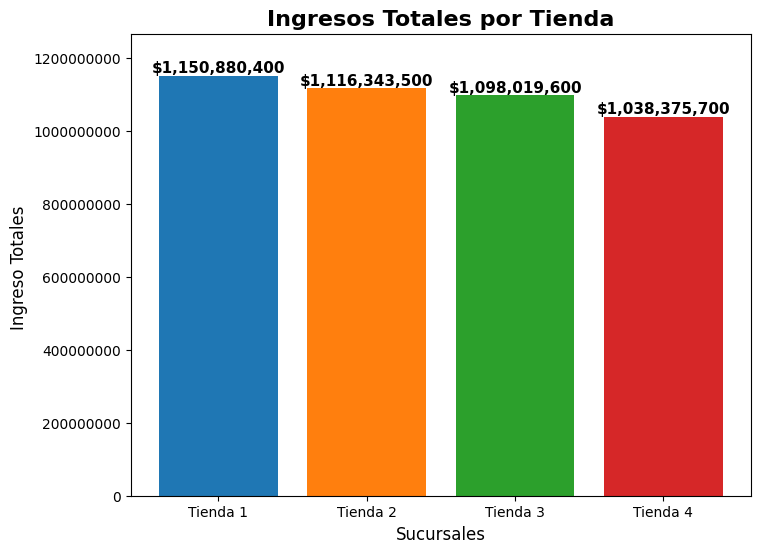

In [12]:
#  GRÁFICO DE BARRAS:

fig, ax = plt.subplots(figsize=(8, 6))

# Grafico de barras con colores diferentes para distinguirlas
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
ax.bar(ingresos_totales.index, ingresos_totales.values, color=colores)

ax.set_title("Ingresos Totales por Tienda", fontsize=16, fontweight='bold')
ax.set_xlabel("Sucursales", fontsize=12)
ax.set_ylabel("Ingreso Totales ", fontsize=12)

# valor exacto de los ingresos encima de cada barra
for i, valor in enumerate(ingresos_totales.values):
    ax.text(i, valor, f'${valor:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.ticklabel_format(style='plain', axis='y')
ax.set_ylim(0, ingresos_totales.max() * 1.1)

plt.show()

# 2. Ventas por categoría

In [13]:
import seaborn as sns


In [14]:
print(" CATEGORÍAS MÁS POPULARES POR TIENDA")

for nombre, df in tiendas.items():
    ventas_categoria = df.groupby('Categoría del Producto').size().sort_values(ascending=False)

    print(f"\nTop 3 categorías de la {nombre} ")

    cuadro_top3 = ventas_categoria.head(3).reset_index()
    cuadro_top3.columns = ['Categoría del Producto', 'Cantidad Vendida']

    display(cuadro_top3)
    print("\n" + "-" * 40 + "\n")



 CATEGORÍAS MÁS POPULARES POR TIENDA

Top 3 categorías de la Tienda 1 


,Categoría del Producto,Cantidad Vendida
0,Muebles,465
1,Electrónicos,448
2,Juguetes,324



----------------------------------------


Top 3 categorías de la Tienda 2 


,Categoría del Producto,Cantidad Vendida
0,Muebles,442
1,Electrónicos,422
2,Juguetes,313



----------------------------------------


Top 3 categorías de la Tienda 3 


,Categoría del Producto,Cantidad Vendida
0,Muebles,499
1,Electrónicos,451
2,Juguetes,315



----------------------------------------


Top 3 categorías de la Tienda 4 


,Categoría del Producto,Cantidad Vendida
0,Muebles,480
1,Electrónicos,451
2,Juguetes,338



----------------------------------------



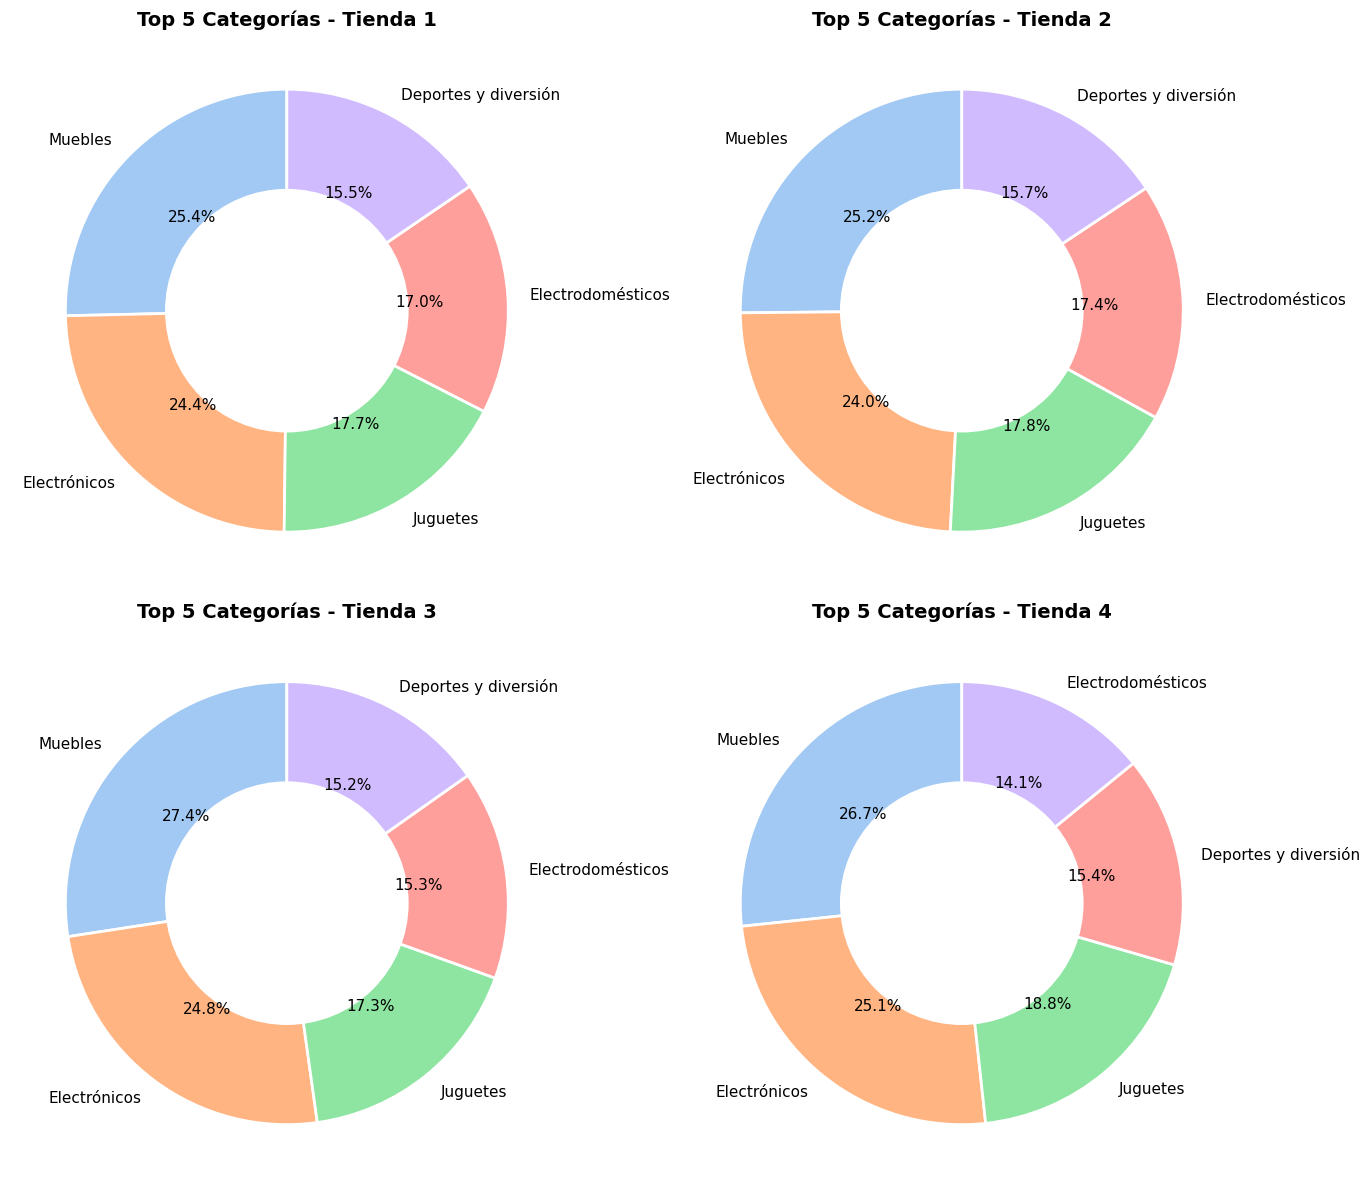

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

colores_pastel = sns.color_palette('pastel')

for i, (nombre, df) in enumerate(tiendas.items()):

    top5 = df['Categoría del Producto'].value_counts().head(5)
    axes[i].pie(
        top5.values,
        labels=top5.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colores_pastel,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
        textprops={'fontsize': 11}
    )

    centro_blanco = plt.Circle((0,0), 0.55, fc='white')
    axes[i].add_artist(centro_blanco)

    axes[i].set_title(f"Top 5 Categorías - {nombre}", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# 3. Calificación promedio de la tienda


In [16]:
datos_calificacion = []

for nombre, df in tiendas.items():
    promedio_actual = df['Calificación'].mean()
    datos_calificacion.append({
        'Tienda': nombre,
        'Calificación': round(promedio_actual, 2)
    })

df_calificaciones = pd.DataFrame(datos_calificacion)
display(df_calificaciones)
print("\n" + "-" * 27 + "\n")


,Tienda,Calificación
0,Tienda 1,3.98
1,Tienda 2,4.04
2,Tienda 3,4.05
3,Tienda 4,4.00



---------------------------



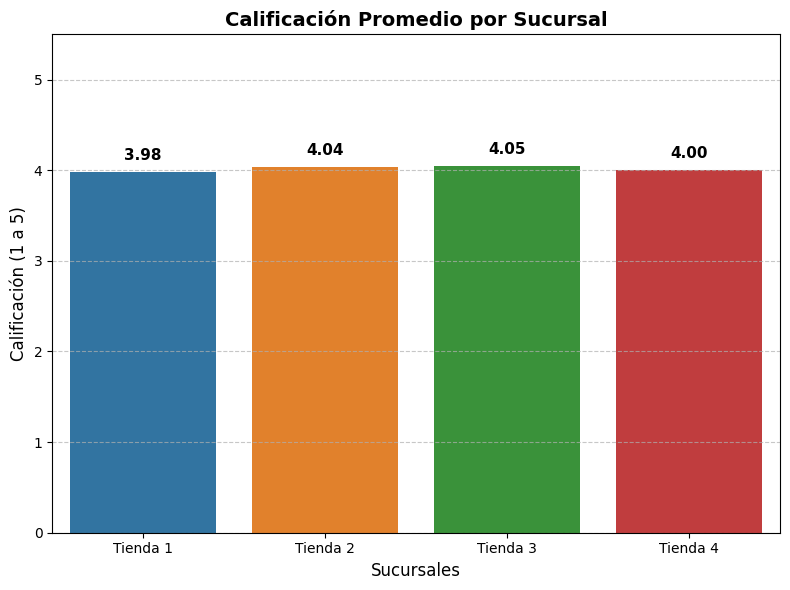

In [17]:
from IPython.display import display
# 2. Visualización: Gráfico de Barras
plt.figure(figsize=(8, 6))
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
ax = sns.barplot(x='Tienda', y='Calificación', data=df_calificaciones, palette=colores, hue='Tienda', legend=False)

plt.title('Calificación Promedio por Sucursal', fontsize=14, fontweight='bold')
plt.xlabel('Sucursales', fontsize=12)
plt.ylabel('Calificación (1 a 5)', fontsize=12)

plt.ylim(0, 5.5)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, valor in enumerate(df_calificaciones['Calificación']):
    ax.text(i, valor + 0.1, f'{valor:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 4. Productos más y menos vendidos

In [18]:
def prod_mas_vendidos(dataset):
    return dataset['Producto'].value_counts().head(3).reset_index(name='Cantidad Vendida')

def prod_menos_vendidos(dataset):
    return dataset['Producto'].value_counts(ascending=True).head(3).reset_index(name='Cantidad Vendida')



In [19]:
print("PRODUCTOS MÁS Y MENOS VENDIDOS POR TIENDA\n")
resultados_tiendas = {}

for nombre, df in tiendas.items():
    top3 = prod_mas_vendidos(df)
    bottom3 = prod_menos_vendidos(df)

    resultados_tiendas[nombre] = {'Top': top3, 'Bottom': bottom3}

    print(f"{nombre}\n")
    print("\nTop 3 Más vendidos:")
    display(top3)
    print("\nTop 3 Menos vendidos:")
    display(bottom3)
    print("\n" + "="*40 + "\n")


PRODUCTOS MÁS Y MENOS VENDIDOS POR TIENDA

Tienda 1


Top 3 Más vendidos:


,Producto,Cantidad Vendida
0,Microondas,60
1,TV LED UHD 4K,60
2,Armario,60



Top 3 Menos vendidos:


,Producto,Cantidad Vendida
0,Auriculares con micrófono,33
1,Celular ABXY,33
2,Olla de presión,35




Tienda 2


Top 3 Más vendidos:


...

,Producto,Cantidad Vendida
0,Bloques de construcción,35
1,Set de vasos,36
2,Microondas,36




Tienda 4


Top 3 Más vendidos:


,Producto,Cantidad Vendida
0,Cama box,62
1,Cubertería,59
2,Dashboards con Power BI,56



Top 3 Menos vendidos:


,Producto,Cantidad Vendida
0,Guitarra eléctrica,33
1,Armario,34
2,Guitarra acústica,37


GRAFICO DE BARRAS HORIZONTALES

Compar los productos mas y menos vendidos por cada tienda

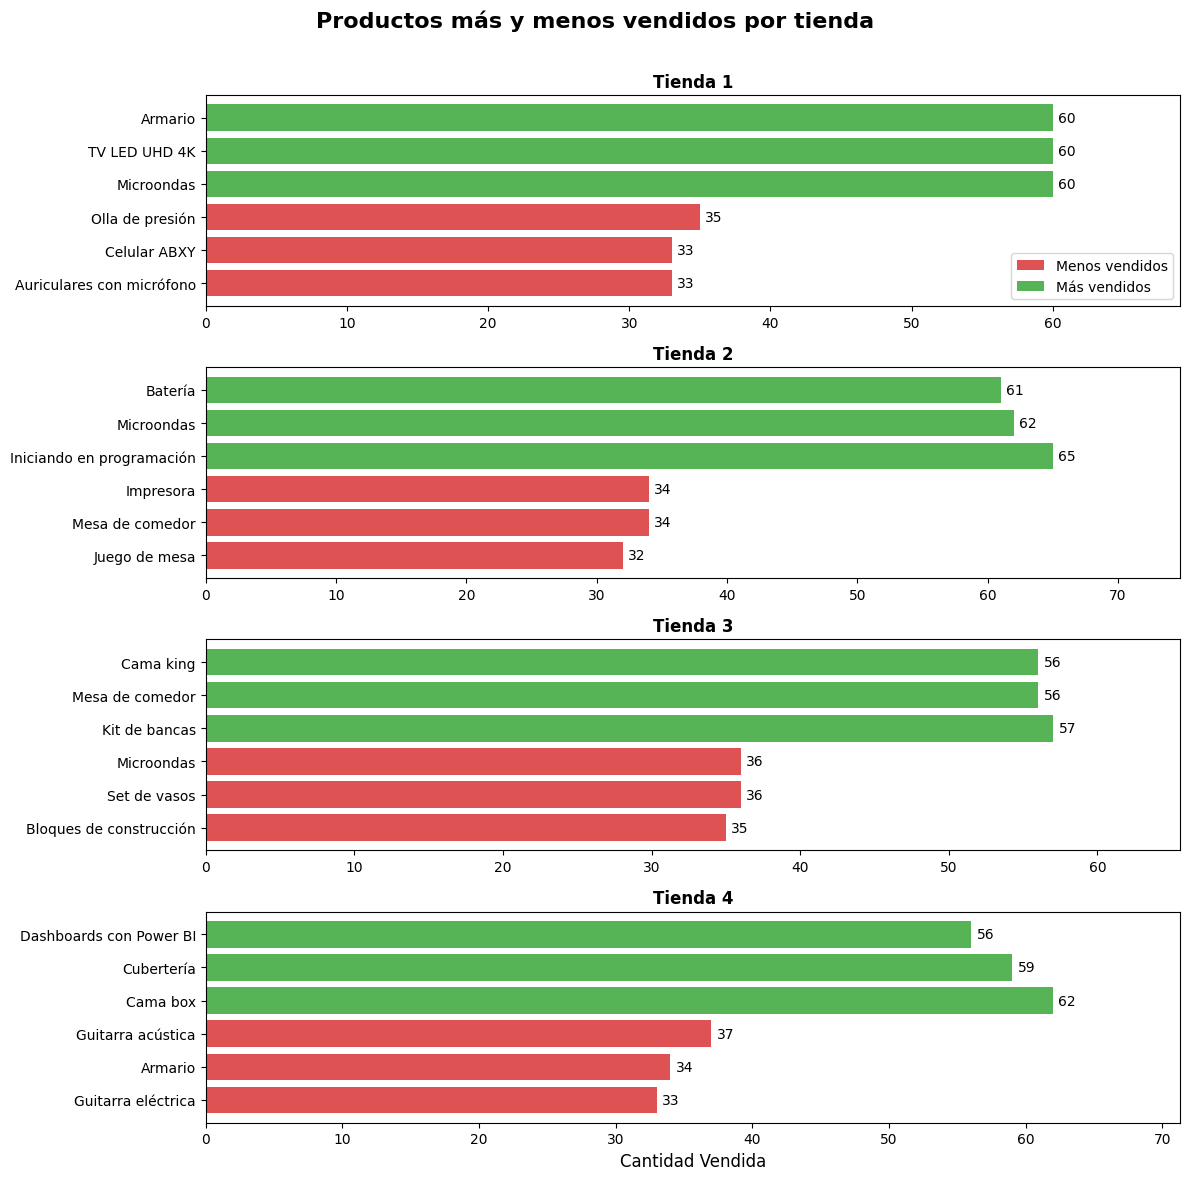

In [20]:
fig, axes = plt.subplots(4, 1, figsize=(12, 12))
fig.suptitle('Productos más y menos vendidos por tienda', fontsize=16, fontweight='bold')

for i, (nombre, datos) in enumerate(resultados_tiendas.items()):
    ax = axes[i]
    top3 = datos['Top']
    bottom3 = datos['Bottom']

    ax.barh(bottom3['Producto'], bottom3['Cantidad Vendida'], color='#d62728', alpha=0.8, label='Menos vendidos')
    ax.barh(top3['Producto'], top3['Cantidad Vendida'], color='#2ca02c', alpha=0.8, label='Más vendidos')

    ax.set_title(nombre, fontsize=12, fontweight='bold')

    for bars in ax.containers:
        ax.bar_label(bars, fmt='%.0f', label_type='edge', padding=4, fontsize=10)

    ax.set_xlim(0, top3['Cantidad Vendida'].max() * 1.15)

axes[3].set_xlabel('Cantidad Vendida', fontsize=12)
axes[0].legend(loc='lower right')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# 5. Envío promedio por tienda

In [21]:
datos_envio = []

for nombre, df in tiendas.items():
    envio_promedio = df['Costo de envío'].mean()
    datos_envio.append({
        'Tienda': nombre,
        'Costo de Envío Promedio': round(envio_promedio, 2)
    })

df_envios = pd.DataFrame(datos_envio)
display(df_envios)


,Tienda,Costo de Envío Promedio
0,Tienda 1,26018.61
1,Tienda 2,25216.24
2,Tienda 3,24805.68
3,Tienda 4,23459.46


GRAFICO DE LINEAS

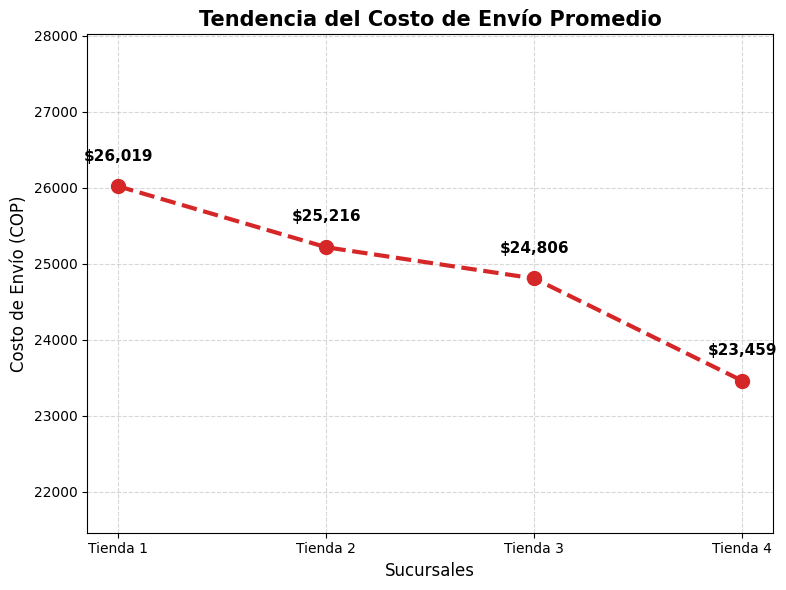

In [22]:
plt.figure(figsize=(8, 6))
plt.plot(
    df_envios['Tienda'],
    df_envios['Costo de Envío Promedio'],
    color='#d62728',
    marker='o',
    markersize=10,
    linewidth=3,
    linestyle='dashed'
)

plt.title('Tendencia del Costo de Envío Promedio', fontsize=15, fontweight='bold')
plt.xlabel('Sucursales', fontsize=12)
plt.ylabel('Costo de Envío (COP)', fontsize=12)
 #LIMITE
min_envio = df_envios['Costo de Envío Promedio'].min()
max_envio = df_envios['Costo de Envío Promedio'].max()
plt.ylim(min_envio - 2000, max_envio + 2000)

plt.grid(axis='both', linestyle='--', alpha=0.5)

for i, valor in enumerate(df_envios['Costo de Envío Promedio']):
    plt.text(i, valor + 300, f'${valor:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# **INFORME FINAL**

 Respecto a los resultados del análisis de datos de las cuatro sucursales de **Alura Store** y con base en estos hallazgos, se recomienda para ayudar al Sr. Juan a decidir qué tienda debe vender para financiar su nuevo emprendimiento, asegurando el menor impacto negativo en la rentabilidad general de la empresa.

Tras el análisis y visualización del conjunto de datos, se identificaron los siguientes patrones clave:

* **Ingresos Totales:** Existe una clara diferencia en la facturación. La `Tienda 1` es la más rentable, superando los` $1,150` millones.
 Por el contrario, la `Tienda 4` registra los ingresos más bajos de toda la cadena, con apenas `$1,038 `millones.
* **Categorías y Productos:** La categoría de *Muebles* domina el mercado en todas las sucursales. Sin embargo, al observar los productos estrella, las tiendas líderes facturan con artículos de alto ticket (como *TVs LED UHD 4K* o *Iphones 15*). En la `Tienda 4`, los productos más vendidos son de menor valor (*Camas Box* y *Cubertería*).
* **Satisfacción del Cliente:** La calidad del servicio se mantiene estable y positiva en toda la cadena. Las calificaciones promedio de los clientes no muestran variaciones alarmantes, manteniéndose alrededor de las **4.0 estrellas** en las cuatro tiendas.
* **Costo de Envío Promedio:** Los datos revelan que la `Tienda 4 `ofrece a los clientes el costo de envío más económico
(`$23,459 `  en  promedio, frente a los más de `$26,000`  de la `Tienda 1`).

## En Conclusión
Con base en la evidencia de los datos analizados, **se recomienda que el Sr. Juan proceda con la venta de la Tienda 4.**

Ya que,a pesar de que la Tienda 4 cuenta con la ventaja logística de ofrecer los envíos más baratos y mantiene una excelente calificación de satisfacción por parte de los clientes, **no logra traducir estas fortalezas en volumen de facturación**.
Su dependencia de productos de menor valor genera que sus ingresos totales sean los más bajos del grupo.
